# 19. Evaluación de la profundidad refinada

Este notebook evalúa el checkpoint obtenido tras entrenar el modelo de refinamiento de profundidad. Por defecto, se utiliza la variante `Depth Pro + RGB` entrenada con el dataset ampliado `depth_refinement_dataset_first30`, siempre que esté disponible. En caso contrario, se emplea como alternativa el dataset anterior de 5 samples.

La comparación principal se realiza entre la profundidad original estimada por Depth Pro y la profundidad refinada por el modelo, utilizando como referencia la profundidad LiDAR proyectada sobre la imagen.

Además de las métricas cuantitativas, el notebook incluye una visualización de 10 ejemplos, donde se muestran la entrada, la etiqueta LiDAR sparse y la salida refinada. Esta revisión visual permite comprobar de forma cualitativa si el refinamiento mejora la coherencia de las predicciones de profundidad.

In [ ]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'scripts' / 'train_depth_refiner.py').exists():
    for parent in Path.cwd().resolve().parents:
        if (parent / 'scripts' / 'train_depth_refiner.py').exists():
            ROOT = parent
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SCENE_DIR = ROOT / 'outputs' / 'scene-0061'
PREFERRED_DATASET_NAMES = [
    'depth_refinement_dataset_first30',
    'depth_refinement_dataset',
    'depth_refinement_dataset_front_smoke',
]

REFINER_VARIANT = 'refiner_training_rgb'
EVALUATE_VALIDATION_ONLY = True
SAVE_REFINED_DEPTH_EVAL = True
VISUALIZATION_EXAMPLES = 10

available_datasets = [SCENE_DIR / name for name in PREFERRED_DATASET_NAMES if (SCENE_DIR / name / 'dataset_index.json').exists()]
DATASET_DIR = available_datasets[0] if available_datasets else SCENE_DIR / PREFERRED_DATASET_NAMES[0]
TRAINING_DIR = DATASET_DIR / REFINER_VARIANT
CHECKPOINT = TRAINING_DIR / 'best_depth_refiner.pt'
BASELINE_PATH = TRAINING_DIR / 'baseline_depth_pro_metrics.json'
EVAL_OUTPUT_PATH = TRAINING_DIR / 'refined_depth_eval.json'
EXAMPLES_OUTPUT_PATH = TRAINING_DIR / f'refined_depth_examples_{VISUALIZATION_EXAMPLES}.png'

print('Python kernel:', sys.executable)
print('Dataset seleccionado:', DATASET_DIR)
print('Datasets candidatos:', [str(path) for path in available_datasets])
print('Training dir:', TRAINING_DIR)
print('Checkpoint:', CHECKPOINT)
print('EVALUATE_VALIDATION_ONLY:', EVALUATE_VALIDATION_ONLY)
print('SAVE_REFINED_DEPTH_EVAL:', SAVE_REFINED_DEPTH_EVAL)
print('VISUALIZATION_EXAMPLES:', VISUALIZATION_EXAMPLES)


Python kernel: /home/clara/ml-depth-pro/depthpro_env/bin/python
Dataset seleccionado: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30
Datasets candidatos: ['/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30', '/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset', '/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_front_smoke']
Training dir: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb
Checkpoint: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb/best_depth_refiner.pt
EVALUATE_VALIDATION_ONLY: True
SAVE_REFINED_DEPTH_EVAL: True
VISUALIZATION_EXAMPLES: 10


## 1. Estado de los archivos

Antes de ejecutar la evaluación, es necesario comprobar que existen tanto el dataset de refinamiento como el checkpoint entrenado.

Si el entrenamiento se ha realizado con la versión actualizada del script, el fichero `baseline_depth_pro_metrics.json` incluye también el campo `split_details`. Esta información permite recuperar la partición utilizada durante el entrenamiento y evaluar únicamente sobre el split de validación.

In [2]:
index_path = DATASET_DIR / 'dataset_index.json'

print('dataset_index existe:', index_path.exists())
print('checkpoint existe:', CHECKPOINT.exists())
print('baseline metrics existe:', BASELINE_PATH.exists())

if index_path.exists():
    index = json.loads(index_path.read_text(encoding='utf-8-sig'))
    print('Entradas:', index['num_entries'])
if BASELINE_PATH.exists():
    baseline = json.loads(BASELINE_PATH.read_text(encoding='utf-8-sig'))
    print('split_note:', baseline.get('split_note'))
    print('split_by_sample:', baseline.get('split_by_sample'))
    print('train entries:', baseline.get('num_train_entries'))
    print('val entries:', baseline.get('num_val_entries'))

dataset_index existe: True
checkpoint existe: True
baseline metrics existe: True
Entradas: 180
split_note: sample_token_grouped_split
split_by_sample: True
train entries: 144
val entries: 36


## 2. Comparación en píxeles LiDAR válidos

Esta evaluación compara el MAE y el RMSE, expresados en metros, únicamente en los píxeles donde la profundidad LiDAR proyectada es válida.

Si `EVALUATE_VALIDATION_ONLY = True`, se utilizan solo los índices de validación guardados durante el entrenamiento. En cambio, si el checkpoint corresponde a una versión anterior y no existe información de `split_details`, el notebook muestra un aviso y evalúa todas las entradas disponibles.

In [3]:
from scripts.train_depth_refiner import SmallDepthUNet

def metric_totals(pred, target, mask):
    valid = mask > 0
    if valid.sum() == 0:
        return {'abs_error_sum_m': 0.0, 'sq_error_sum_m2': 0.0, 'valid_pixels': 0}
    diff = pred[valid] - target[valid]
    return {
        'abs_error_sum_m': float(np.sum(np.abs(diff))),
        'sq_error_sum_m2': float(np.sum(diff ** 2)),
        'valid_pixels': int(valid.sum()),
    }

def summarize_totals(abs_error_sum_m, sq_error_sum_m2, valid_pixels):
    if valid_pixels == 0:
        return {'mae_m': np.nan, 'rmse_m': np.nan, 'valid_pixels': 0}
    return {
        'mae_m': float(abs_error_sum_m / valid_pixels),
        'rmse_m': float(np.sqrt(sq_error_sum_m2 / valid_pixels)),
        'valid_pixels': int(valid_pixels),
    }

def load_refiner(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    input_channels = int(checkpoint.get('input_channels', 1))
    model = SmallDepthUNet(base_channels=checkpoint['base_channels'], in_channels=input_channels)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    use_rgb = bool(checkpoint.get('use_rgb', input_channels == 4))
    return model, float(checkpoint['max_depth']), use_rgb, checkpoint

def build_refiner_input(depth_pro, rgb, max_depth, use_rgb):
    channels = [np.clip(depth_pro / max_depth, 0, 1)[None].astype(np.float32)]
    if use_rgb:
        channels.append(np.transpose(rgb.astype(np.float32) / 255.0, (2, 0, 1)))
    return torch.from_numpy(np.concatenate(channels, axis=0)[None])

def selected_entries(index, checkpoint):
    entries = index['entries']
    split_details = checkpoint.get('split_details')
    if EVALUATE_VALIDATION_ONLY and split_details and 'val_indices' in split_details:
        indices = [int(idx) for idx in split_details['val_indices']]
        print('Evaluando solo validacion. Indices:', indices)
        return [entries[idx] for idx in indices], 'validation'
    if EVALUATE_VALIDATION_ONLY:
        print('Aviso: no hay split_details en el checkpoint. Se evaluan todas las entradas.')
    return entries, 'all'

if not index_path.exists() or not CHECKPOINT.exists():
    print('Falta dataset o checkpoint. Ejecuta primero los notebooks 17 y 18.')
else:
    index = json.loads(index_path.read_text(encoding='utf-8-sig'))
    model, max_depth, use_rgb, checkpoint = load_refiner(CHECKPOINT)
    entries_to_eval, eval_split = selected_entries(index, checkpoint)
    rows = []
    totals = {
        'depth_pro': {'abs_error_sum_m': 0.0, 'sq_error_sum_m2': 0.0, 'valid_pixels': 0},
        'refined': {'abs_error_sum_m': 0.0, 'sq_error_sum_m2': 0.0, 'valid_pixels': 0},
    }

    with torch.no_grad():
        for entry in entries_to_eval:
            data = np.load(DATASET_DIR / entry['npz_path'])
            depth_pro = data['depth_pro'].astype(np.float32)
            rgb = data['rgb']
            gt_depth = data['gt_depth'].astype(np.float32)
            mask = data['valid_mask'].astype(bool)

            inp = build_refiner_input(depth_pro, rgb, max_depth, use_rgb)
            refined = model(inp).squeeze().numpy().astype(np.float32) * max_depth

            depth_pro_totals = metric_totals(depth_pro, gt_depth, mask)
            refined_totals = metric_totals(refined, gt_depth, mask)
            for source, source_totals in [('depth_pro', depth_pro_totals), ('refined', refined_totals)]:
                for key, value in source_totals.items():
                    totals[source][key] += value

            depth_pro_metrics = summarize_totals(**depth_pro_totals)
            refined_metrics = summarize_totals(**refined_totals)
            rows.append({
                'sample_index': entry['sample_index'],
                'sample_token': entry['sample_token'],
                'channel': entry['channel'],
                'valid_pixels': depth_pro_metrics['valid_pixels'],
                'depth_pro_mae_m': depth_pro_metrics['mae_m'],
                'refined_mae_m': refined_metrics['mae_m'],
                'delta_mae_m': refined_metrics['mae_m'] - depth_pro_metrics['mae_m'],
                'depth_pro_rmse_m': depth_pro_metrics['rmse_m'],
                'refined_rmse_m': refined_metrics['rmse_m'],
                'delta_rmse_m': refined_metrics['rmse_m'] - depth_pro_metrics['rmse_m'],
            })

    results = {
        'checkpoint': str(CHECKPOINT),
        'dataset_dir': str(DATASET_DIR),
        'eval_split': eval_split,
        'evaluate_validation_only': EVALUATE_VALIDATION_ONLY,
        'use_rgb': use_rgb,
        'num_entries': len(entries_to_eval),
        'aggregate': {
            'depth_pro': summarize_totals(**totals['depth_pro']),
            'refined': summarize_totals(**totals['refined']),
        },
        'rows': rows,
    }
    results['aggregate']['delta_mae_m'] = results['aggregate']['refined']['mae_m'] - results['aggregate']['depth_pro']['mae_m']
    results['aggregate']['delta_rmse_m'] = results['aggregate']['refined']['rmse_m'] - results['aggregate']['depth_pro']['rmse_m']

    rows_df = pd.DataFrame(rows)
    display(pd.DataFrame([
        {'source': 'Depth Pro', **results['aggregate']['depth_pro']},
        {'source': 'Refinada', **results['aggregate']['refined']},
    ]))
    print('Delta MAE refinada - Depth Pro:', results['aggregate']['delta_mae_m'])
    print('Delta RMSE refinada - Depth Pro:', results['aggregate']['delta_rmse_m'])
    display(rows_df)

    if SAVE_REFINED_DEPTH_EVAL:
        EVAL_OUTPUT_PATH.write_text(json.dumps(results, indent=2), encoding='utf-8')
        print('Guardado:', EVAL_OUTPUT_PATH)

Evaluando solo validacion. Indices: [36, 37, 38, 39, 40, 41, 48, 49, 50, 51, 52, 53, 72, 73, 74, 75, 76, 77, 84, 85, 86, 87, 88, 89, 126, 127, 128, 129, 130, 131, 168, 169, 170, 171, 172, 173]


,source,mae_m,rmse_m,valid_pixels
0,Depth Pro,4.113208,29.378440,128336
1,Refinada,2.838228,5.907853,128336


Delta MAE refinada - Depth Pro: -1.274979714428215
Delta RMSE refinada - Depth Pro: -23.470587570228037


,sample_index,sample_token,channel,valid_pixels,depth_pro_mae_m,refined_mae_m,delta_mae_m,depth_pro_rmse_m,refined_rmse_m,delta_rmse_m
0,6,4f545737bf3347fbbc9af60b0be9a963,CAM_FRONT_LEFT,3611,1.318826,1.211043,-0.107783,2.510159,2.105138,-0.405022
1,6,4f545737bf3347fbbc9af60b0be9a963,CAM_FRONT,2814,2.538975,2.222504,-0.316471,7.262848,5.113393,-2.149456
2,6,4f545737bf3347fbbc9af60b0be9a963,CAM_FRONT_RIGHT,3228,3.143286,3.885640,0.742353,8.121846,6.876754,-1.245092
3,6,4f545737bf3347fbbc9af60b0be9a963,CAM_BACK_RIGHT,3283,6.925967,4.605576,-2.320391,11.825837,7.942030,-3.883807
4,6,4f545737bf3347fbbc9af60b0be9a963,CAM_BACK,4443,4.216057,2.644814,-1.571243,8.683956,5.556552,-3.127403
5,6,4f545737bf3347fbbc9af60b0be9a963,CAM_BACK_LEFT,4112,1.612183,1.035125,-0.577059,2.580101,1.901943,-0.678158
6,8,be99ffc878b24aca8956bbb4e0f97d0c,CAM_FRONT_LEFT,3566,1.667792,2.436634,0.768842,3.862221,4.263859,0.401638
7,8,be99ffc878b24aca8956bbb4e0f97d0c,CAM_FRONT,2802,3.356765,2.189035,-1.167731,6.762972,4.974536,-1.788436
8,8,be99ffc878b24aca8956bbb4e0f97d0c,CAM_FRONT_RIGHT,3042,4.111738,3.688780,-0.422958,12.183796,7.345410,-4.838386
9,8,be99ffc878b24aca8956bbb4e0f97d0c,CAM_BACK_RIGHT,3571,5.690459,3.802332,-1.888127,10.623417,7.423272,-3.200145


Guardado: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb/refined_depth_eval.json


## 3. Visualización de 10 ejemplos

Esta celda visualiza hasta `VISUALIZATION_EXAMPLES` entradas, seleccionadas preferentemente del split de validación.

Cada fila muestra la imagen RGB utilizada como contexto, la profundidad original estimada por `Depth Pro`, la etiqueta sparse obtenida al proyectar `LIDAR_TOP` sobre la cámara y la salida refinada del modelo.

Esta comparación permite revisar de forma cualitativa si el modelo corrige la profundidad inicial en las zonas con supervisión LiDAR y si mantiene una estructura coherente en el resto de la imagen.

Visualizando entradas de validacion: [36, 37, 38, 39, 40, 41, 48, 49, 50, 51]
Figura guardada en: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb/refined_depth_examples_10.png


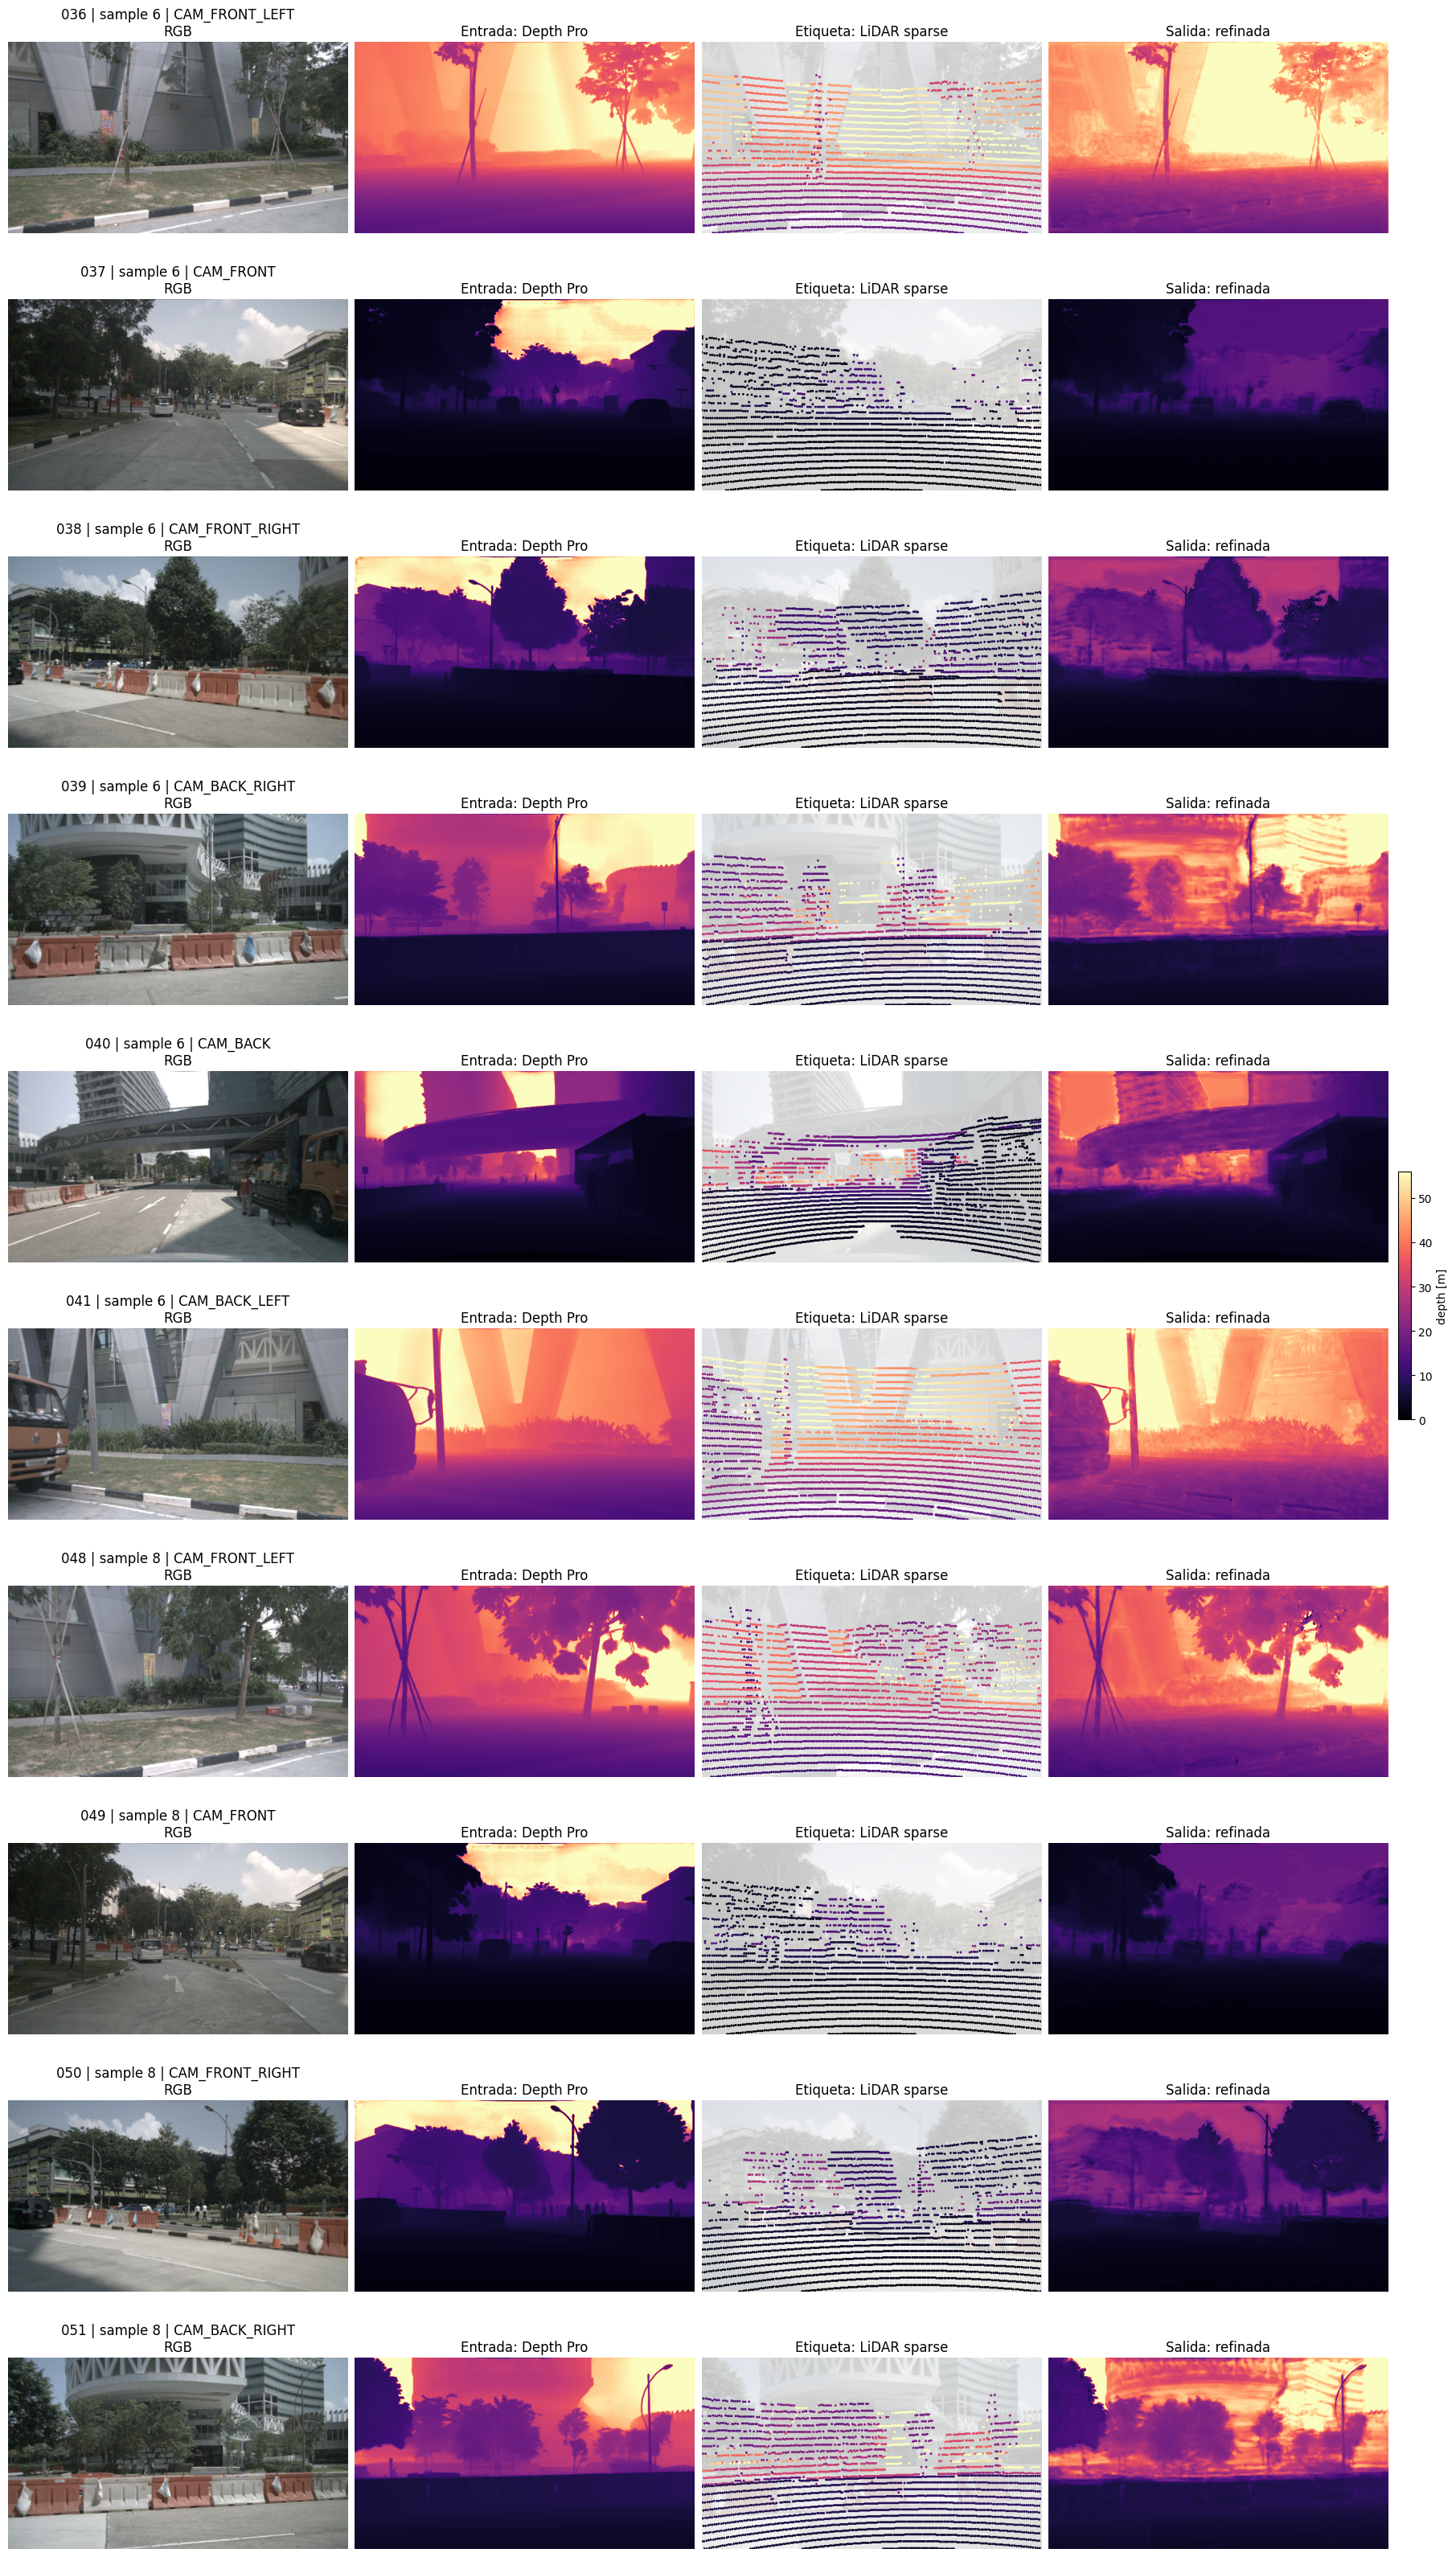

In [4]:
if index_path.exists() and CHECKPOINT.exists():
    index = json.loads(index_path.read_text(encoding='utf-8-sig'))
    model, max_depth, use_rgb, checkpoint = load_refiner(CHECKPOINT)

    split_details = checkpoint.get('split_details')
    if EVALUATE_VALIDATION_ONLY and split_details and split_details.get('val_indices'):
        selected_indices = [int(idx) for idx in split_details['val_indices']]
        print('Visualizando entradas de validacion:', selected_indices[:VISUALIZATION_EXAMPLES])
    else:
        selected_indices = list(range(len(index['entries'])))
        print('Visualizando primeras entradas del dataset.')
    selected_indices = selected_indices[:VISUALIZATION_EXAMPLES]

    if not selected_indices:
        print('No hay entradas para visualizar.')
    else:
        fig, axes = plt.subplots(
            len(selected_indices),
            4,
            figsize=(18, 3.2 * len(selected_indices)),
            constrained_layout=True,
        )
        if len(selected_indices) == 1:
            axes = np.asarray([axes])

        depth_cmap = plt.cm.magma.copy()
        sparse_cmap = plt.cm.magma.copy()
        sparse_cmap.set_bad(color='white')

        for row, entry_idx in enumerate(selected_indices):
            entry = index['entries'][entry_idx]
            data = np.load(DATASET_DIR / entry['npz_path'])
            rgb = data['rgb']
            depth_pro = data['depth_pro'].astype(np.float32)
            gt_depth = data['gt_depth'].astype(np.float32)
            mask = data['valid_mask'].astype(bool)

            with torch.no_grad():
                inp = build_refiner_input(depth_pro, rgb, max_depth, use_rgb)
                refined = model(inp).squeeze().numpy() * max_depth

            valid_depths = gt_depth[mask]
            finite_depth_pro = depth_pro[np.isfinite(depth_pro)]
            if valid_depths.size:
                vmax = float(np.nanpercentile(np.concatenate([finite_depth_pro, valid_depths]), 95))
            else:
                vmax = float(np.nanpercentile(finite_depth_pro, 95))
            vmax = max(vmax, 1.0)

            title_prefix = f"{entry_idx:03d} | sample {entry['sample_index']} | {entry['channel']}"
            axes[row, 0].imshow(rgb)
            axes[row, 0].set_title(title_prefix + '\nRGB')

            im_depth = axes[row, 1].imshow(np.clip(depth_pro, 0, vmax), cmap=depth_cmap, vmin=0, vmax=vmax)
            axes[row, 1].set_title('Entrada: Depth Pro')

            axes[row, 2].imshow(rgb, alpha=0.25)
            ys, xs = np.where(mask)
            axes[row, 2].scatter(xs, ys, c=gt_depth[ys, xs], s=1.2, cmap=sparse_cmap, vmin=0, vmax=vmax)
            axes[row, 2].set_title('Etiqueta: LiDAR sparse')

            axes[row, 3].imshow(np.clip(refined, 0, vmax), cmap=depth_cmap, vmin=0, vmax=vmax)
            axes[row, 3].set_title('Salida: refinada')

            for col in range(4):
                axes[row, col].axis('off')

        cbar = fig.colorbar(im_depth, ax=axes[:, 1:].ravel().tolist(), fraction=0.012, pad=0.01)
        cbar.set_label('depth [m]')
        EXAMPLES_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(EXAMPLES_OUTPUT_PATH, dpi=160)
        print('Figura guardada en:', EXAMPLES_OUTPUT_PATH)
        plt.show()
else:
    print('Falta dataset o checkpoint.')


## 4. Conclusiones

El refinamiento mejora de forma clara la profundidad estimada por Depth Pro en el split de validación. El MAE se reduce de `4.11 m` a `2.84 m`, calculado sobre 128336 píxeles LiDAR válidos. Esta mejora indica que la U-Net con entrada `Depth Pro + RGB` aprende una corrección útil hacia la profundidad métrica proporcionada por `LIDAR_TOP`.

La RMSE también disminuye de `29.38 m` a `5.91 m`. Aun así, conviene analizar esta mejora con cuidado, ya que la profundidad original de Depth Pro contiene algunos outliers de gran magnitud que afectan especialmente a esta métrica.

Las visualizaciones cualitativas muestran que la salida refinada conserva una predicción densa y, al mismo tiempo, aparece más alineada con la supervisión sparse de LiDAR. En conjunto, el modelo cumple el objetivo de mejorar la profundidad antes de regenerar la pseudo-LiDAR y evaluar su impacto posterior en las métricas 3D y de registro temporal.